In [31]:
print("HELLO NAGASAI !")

HELLO NAGASAI !


In [32]:
import pandas as pd

df = pd.read_csv("styles.csv")

print(df.head())

ParserError: Error tokenizing data. C error: Expected 10 fields in line 6044, saw 11


In [ ]:
import pandas as pd

df = pd.read_csv("styles.csv")

print(df.head())

ParserError: Error tokenizing data. C error: Expected 10 fields in line 6044, saw 11


In [ ]:
import pandas as pd

df = pd.read_csv("styles.csv", on_bad_lines="skip")
print(df.head())

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  


In [ ]:
print(df.shape)
print(df.columns)
print(df.info())

(44424, 10)
Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB
None


In [ ]:
import os

image_folder = "images"

print("Images count:", len(os.listdir(image_folder)))
print(os.listdir(image_folder)[:5])

Images count: 44441
['10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg']


In [ ]:
import os

print("Total images:", len(os.listdir("images")))

Total images: 44441


In [ ]:
import numpy as np
print(np.__version__)

2.5.1


In [ ]:
import cv2
print(cv2.__version__)

ModuleNotFoundError: No module named 'cv2'

In [ ]:
import cv2
print(cv2.__version__)

5.0.0


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import GlobalMaxPooling2D
from tensorflow.keras.models import Sequential

model = Sequential([
    ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    GlobalMaxPooling2D()
])

model.trainable = False

print("Model loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 41s 0us/step
Model loaded successfully!


In [ ]:
import os

image_files = []

for file in os.listdir("images"):
    image_files.append(os.path.join("images", file))

print("Total image paths:", len(image_files))
print(image_files[:5])

Total image paths: 44441
['images\\10000.jpg', 'images\\10001.jpg', 'images\\10002.jpg', 'images\\10003.jpg', 'images\\10004.jpg']


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

feature_model = model

def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    features = model.predict(img_array, verbose=0)
    features = features.flatten()
    features = features / np.linalg.norm(features)

    return features

print("Feature extraction function ready!")

Feature extraction function ready!


In [ ]:
sample_image = image_files[0]

features = extract_features(sample_image, feature_model)

print("Feature vector length:", len(features))
print(features[:10])

Feature vector length: 2048
[0.         0.01761619 0.00171606 0.00808783 0.0258896  0.01252663
 0.01442037 0.01690398 0.00714529 0.00018298]


In [ ]:
from tqdm import tqdm

feature_list = []

for file in tqdm(image_files):
    feature_list.append(extract_features(file, feature_model))

print("Total feature vectors:", len(feature_list))

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
from tqdm import tqdm

In [ ]:
from tqdm import tqdm
import pickle

feature_list = []

for file in tqdm(image_files):
    feature_list.append(extract_features(file, feature_model))

pickle.dump(feature_list, open("feature_list.pkl", "wb"))
pickle.dump(image_files, open("image_files.pkl", "wb"))

print("Feature extraction completed!")

100%|██████████| 44441/44441 [2:51:16<00:00,  4.32it/s]  


Feature extraction completed!


In [ ]:
import pickle
from sklearn.neighbors import NearestNeighbors

# Saved features load cheyyadam
feature_list = pickle.load(open("feature_list.pkl", "rb"))
image_files = pickle.load(open("image_files.pkl", "rb"))

# Recommendation model create cheyyadam
neighbors = NearestNeighbors(
    n_neighbors=6,
    algorithm="brute",
    metric="euclidean"
)

neighbors.fit(feature_list)

print("Recommendation Model Ready!")

Recommendation Model Ready!


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample_image = image_files[100]   # 100th image select chestunnam

img = Image.open(sample_image)

plt.imshow(img)
plt.axis("off")
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

Matplotlib is building the font cache; this may take a moment.


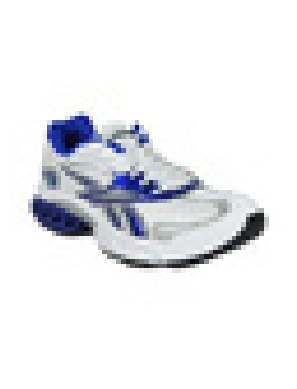

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample_image = image_files[100]   # 100th image select chestunnam

img = Image.open(sample_image)

plt.imshow(img)
plt.axis("off")
plt.show()

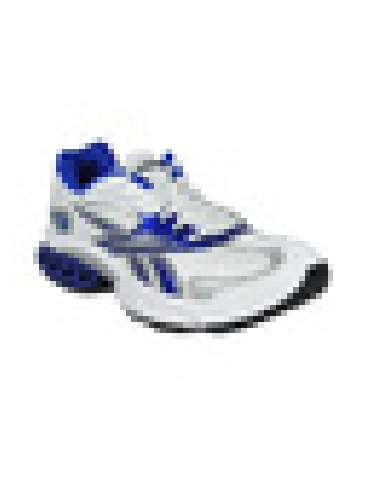

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample_image = image_files[100]

img = Image.open(sample_image)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
query_features = extract_features(sample_image, feature_model)

distances, indices = neighbors.kneighbors([query_features])

print(indices)

[[  100 37394    98 41547 42557  3100]]


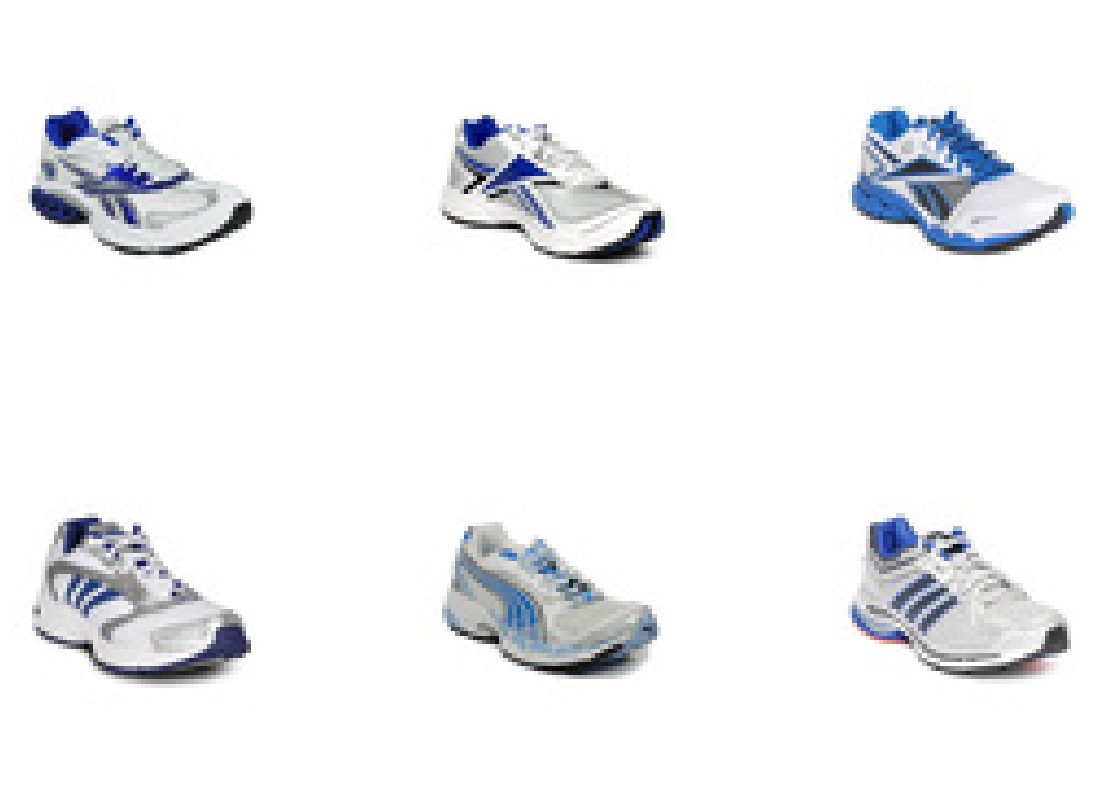

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    img = Image.open(image_files[indices[0][i]])
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [ ]:
def get_free_gift(category):
    gifts = {
        "Shoes": "🎁 Free White Socks",
        "Tshirts": "🎁 Free Cap",
        "Shirts": "🎁 Free Handkerchief",
        "Jeans": "🎁 Free Belt",
        "Kurtas": "🎁 Free Dupatta",
        "Dress": "🎁 Free Handbag"
    }

    return gifts.get(category, "🎁 Free Gift Coupon")

In [ ]:
product_id = int(image_files[100].split("\\")[-1].split(".")[0])

product = df[df["id"] == product_id]

category = product.iloc[0]["articleType"]

print("Category:", category)
print(get_free_gift(category))

NameError: name 'df' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv("styles.csv", on_bad_lines="skip")

In [ ]:
product_id = int(image_files[100].split("\\")[-1].split(".")[0])

product = df[df["id"] == product_id]

category = product.iloc[0]["articleType"]

print("Category:", category)
print(get_free_gift(category))

Category: Sports Shoes
🎁 Free Gift Coupon


In [ ]:
product_id = int(image_files[100].split("\\")[-1].split(".")[0])

product = df[df["id"] == product_id]

category = product.iloc[0]["articleType"]

print("Category:", category)
def get_free_gift(category):
    gifts = {
        "Sports Shoes": "🎁 Free Sports Socks",
        "Casual Shoes": "🎁 Free Shoe Cleaner",
        "Formal Shoes": "🎁 Free Shoe Polish",
        "Flip Flops": "🎁 Free Slippers Bag",

        "Tshirts": "🎁 Free Cap",
        "Shirts": "🎁 Free Handkerchief",
        "Jeans": "🎁 Free Belt",
        "Dress": "🎁 Free Handbag",
        "Kurtas": "🎁 Free Dupatta",
        "Watches": "🎁 Free Watch Box",
        "Handbags": "🎁 Free Keychain"
    }

    return gifts.get(category, "🎁 Free Gift Coupon")


Category: Sports Shoes


In [ ]:
print("Category:", category)
print(get_free_gift(category))

Category: Sports Shoes
🎁 Free Sports Socks


In [ ]:
print("="*40)
print("🎉 SPECIAL OFFER 🎉")
print(get_free_gift(category))
print("="*40)

🎉 SPECIAL OFFER 🎉
🎁 Free Sports Socks


In [ ]:
print("=" * 40)
print("🎉 SPECIAL OFFER 🎉")
print(f"Selected Category: {category}")
print(get_free_gift(category))
print("=" * 40)

🎉 SPECIAL OFFER 🎉
Selected Category: Sports Shoes
🎁 Free Sports Socks
